# Интеллектуальный анализ данных – весна 2025

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def entropy(array: np.ndarray) -> float:
    probs = array / np.sum(array)
    return -np.sum(probs * np.log(probs))
print(round(entropy(np.array([8,2])), 1))

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def gini(array: np.ndarray) -> float:
    probs = array / np.sum(array)
    return 1 - np.sum(probs ** 2)

def info_gain(parent: np.ndarray, left_child: np.ndarray, right_child: np.ndarray, criterion: str = "entropy") -> float:
    def _entropy(arr: np.ndarray) -> float:
        probs = arr / np.sum(arr)
        return -np.sum(probs * np.log(probs))

    def _gini(arr: np.ndarray) -> float:
        probs = arr / np.sum(arr)
        return 1 - np.sum(probs ** 2)

    if criterion == "entropy":
        criterion_func = _entropy
    elif criterion == "gini":
        criterion_func = _gini
    elif criterion == "variance":
        criterion_func = np.var
    else:
        raise ValueError(f"Unknown criterion: {criterion}")
    
    parent_criterion = criterion_func(parent)
    left_criterion = criterion_func(left_child)
    right_criterion = criterion_func(right_child)
    
    weight_left = np.sum(left_child) / np.sum(parent)
    weight_right = np.sum(right_child) / np.sum(parent)
    
    return parent_criterion - (weight_left * left_criterion + weight_right * right_criterion)

print(round(info_gain(np.array([8,2]), np.array([8]), np.array([2]), criterion="gini"), 3))


0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
print(np.mean([1, 10, 5, 18, 100, 30, 50, 61, 84, 47]))

40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [6]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`
    
    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————-
    x = np.asarray(feature_vector).ravel()
    y = np.asarray(target_vector).ravel()
    
    if feature_type == "categorical":
        uniq = np.unique(x)
        classes, y_enc = np.unique(y, return_inverse=True)
        parent_counts = np.bincount(y_enc, minlength=len(classes))
        gains = []
        for val in uniq:
            mask = x == val
            if not mask.any() or mask.all():
                gains.append(-np.inf)
                continue
            left_counts = np.bincount(y_enc[mask], minlength=len(classes))
            right_counts = parent_counts - left_counts
            criterion = "gini" if task == "classification" else "variance"
            gains.append(info_gain(parent_counts, left_counts, right_counts, criterion=criterion))
        gains = np.array(gains)
        best_idx = int(np.argmax(gains))
        return uniq, gains, uniq[best_idx], gains[best_idx]

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    diff = x_sorted[1:] != x_sorted[:-1]
    thresholds = (x_sorted[1:] + x_sorted[:-1]) / 2
    thresholds = thresholds[diff]

    if thresholds.size == 0:
        return np.array([]), np.array([]), None, -np.inf

    n = len(y_sorted)
    left_sizes = np.arange(1, n)
    right_sizes = n - left_sizes

    if task == "classification":
        classes, y_enc = np.unique(y_sorted, return_inverse=True)
        k = len(classes)
        oh = np.eye(k)[y_enc]
        cum = np.cumsum(oh, axis=0)
        left_counts = cum[:-1]
        right_counts = cum[-1] - cum[:-1]

        left_p = left_counts / left_sizes[:, None]
        right_p = right_counts / right_sizes[:, None]
        gini_left = 1 - np.sum(left_p ** 2, axis=1)
        gini_right = 1 - np.sum(right_p ** 2, axis=1)
        parent = 1 - np.sum((cum[-1] / n) ** 2)

    elif task == "regression":
        csum = np.cumsum(y_sorted)
        csum2 = np.cumsum(y_sorted ** 2)
        left_mean = csum[:-1] / left_sizes
        right_mean = (csum[-1] - csum[:-1]) / right_sizes
        left_var = csum2[:-1] / left_sizes - left_mean ** 2
        right_var = (csum2[-1] - csum2[:-1]) / right_sizes - right_mean ** 2
        parent = np.var(y_sorted)
        gini_left, gini_right = left_var, right_var
    else:
        raise ValueError("Unknown task")

    gains_all = parent - (left_sizes / n) * gini_left - (right_sizes / n) * gini_right
    gains = gains_all[diff]

    best_idx = int(np.argmax(gains))
    return thresholds, gains, thresholds[best_idx], gains[best_idx]


Эту функцию можно протестировать на датасете `California`.

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

In [10]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from matplotlib import pyplot as plt
import  seaborn as sns
thresholds, ginis, threshold_best, gini_best = find_best_split(X["MedInc"], y, task="regression", feature_type="real")


In [11]:
thresholds.shape, ginis.shape

((12927,), (12927,))

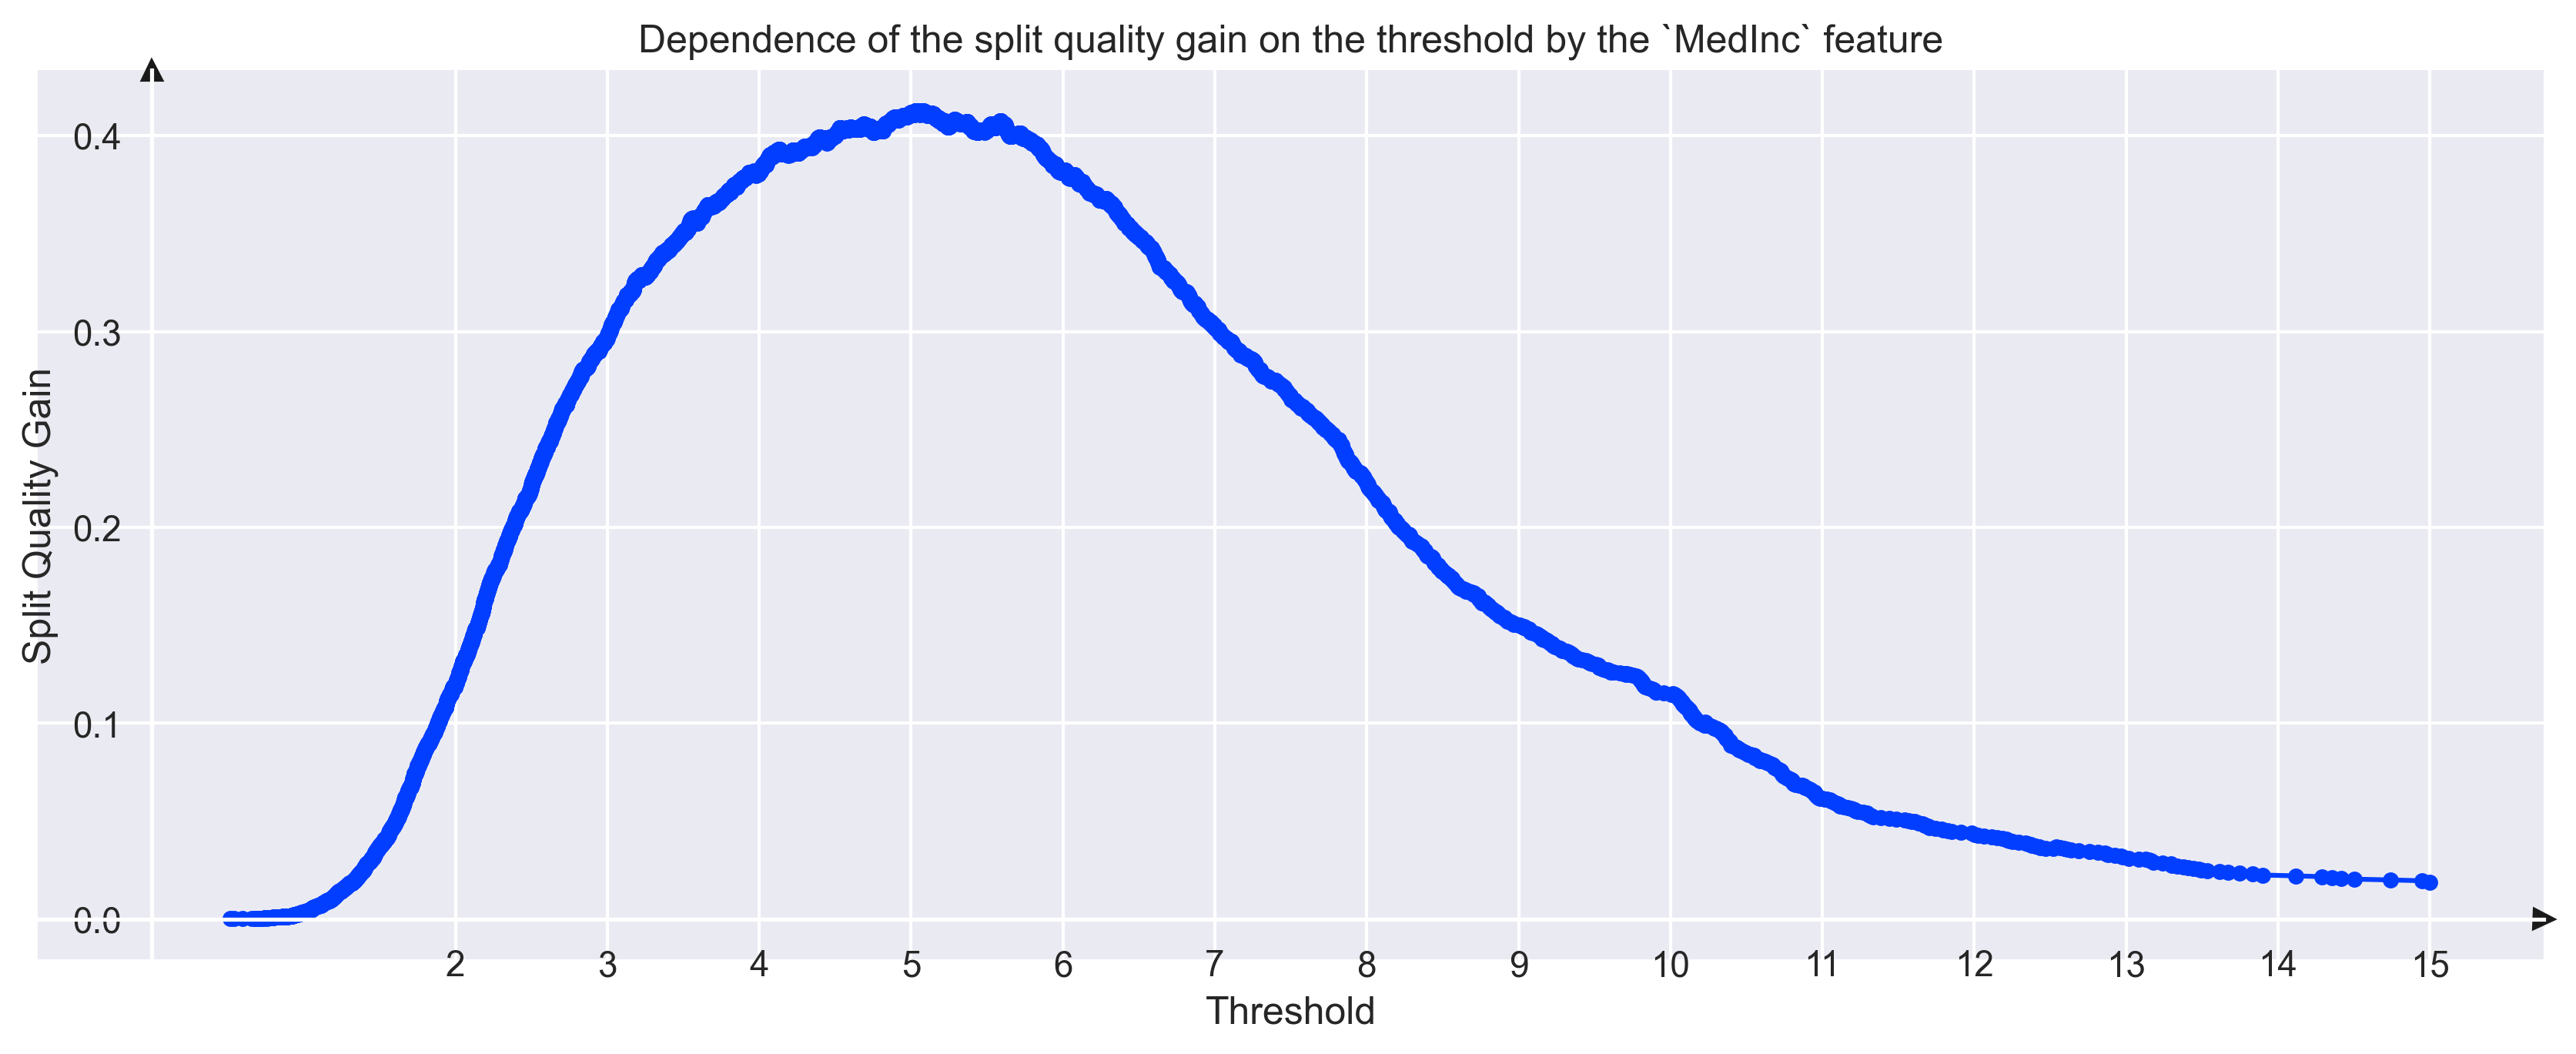

In [12]:
sns.set_theme(palette="bright")
fig, ax = plt.subplots(figsize=(14, 5), dpi=300)

ax.plot(thresholds, ginis, marker="o", markersize=4, label="Split quality gain")
ax.set_xlabel("Threshold")
ax.set_ylabel("Split Quality Gain")
ax.set_xticks(np.arange(int(thresholds.max())) + 2)
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
ax.spines["bottom"].set_position(("data", 0))
ax.spines["left"].set_position(("data", 0))
ax.plot(1, 0, "k>", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.set_title("Dependence of the split quality gain on the threshold by the `MedInc` feature")
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.



In [13]:
best = (-np.inf, None, None)
for feature in X.columns:
    thresholds, gains, thr_best, gain_best = find_best_split(
        X[feature], y, task="regression", feature_type="real"
    )
    if gain_best is not None and gain_best > best[0]:
        best = (gain_best, feature, thr_best)

print(f"Лучший предикат: {best[1]} <= {best[2]} (gain={best[0]:.6f})")

Лучший предикат: MedInc <= 5.03515 (gain=0.412751)


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [14]:
class DecisionTree:
    
    def __init__(
        self, 
        feature_types: Union[List[str], np.ndarray], 
        max_depth: int = None, 
        min_samples_split: int = None, 
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:
        
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}
        
        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types
        
        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        
        # Переменная, если вы решите делать бонус
        self._feature_importances = {}
        self._n_features = None
        

    def _fit_node(
        self, 
        sub_X: np.ndarray, 
        sub_y: np.ndarray, 
        node: dict
    ) -> None:
        sub_X = np.asarray(sub_X)
        sub_y = np.asarray(sub_y)
        
        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)
            
            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = sub_X[:, feature] <= threshold
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = sub_X[:, feature] == threshold
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        if gini_best is not None and np.isfinite(gini_best):
            self._feature_importances[feature_best] = self._feature_importances.get(feature_best, 0.0) + float(gini_best)

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError
            
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
        if node['type'] == 'terminal':
            return node['class']
        
        node_feature = node['feature_split']
        if self._feature_types[node_feature] == 'real':
            if x[node_feature] <= node['threshold']:
                return self._predict_node(x, node['left_child'])
            else:
                return self._predict_node(x, node['right_child'])
        elif self._feature_types[node_feature] == 'categorical':
            if x[node_feature] == node['category_split']:
                return self._predict_node(x, node['left_child'])
            else:
                return self._predict_node(x, node['right_child'])
    

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        X = np.asarray(X)
        y = np.asarray(y)
        self._n_features = X.shape[1]
        self._feature_importances = {}
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
            
        return np.array(predicted)

    def get_feature_importances(self) -> np.ndarray:
        if self._n_features is None:
            return np.array([])
        importances = np.zeros(self._n_features, dtype=float)
        for idx, value in self._feature_importances.items():
            importances[idx] = value
        total = importances.sum()
        if total > 0:
            importances = importances / total
        return importances


**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [15]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
students = pd.read_csv('students.csv')
students.head()

,Unnamed: 0,STG,SCG,STR,LPR,PEG,UNS
0,0,0.00,0.00,0.00,0.00,0.00,0
1,1,0.08,0.08,0.10,0.24,0.90,1
2,2,0.06,0.06,0.05,0.25,0.33,0
3,3,0.10,0.10,0.15,0.65,0.30,1
4,4,0.08,0.08,0.08,0.98,0.24,0


In [16]:
X = students.drop(columns=["UNS", "Unnamed: 0"])
y = students["UNS"]
X.head()

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24


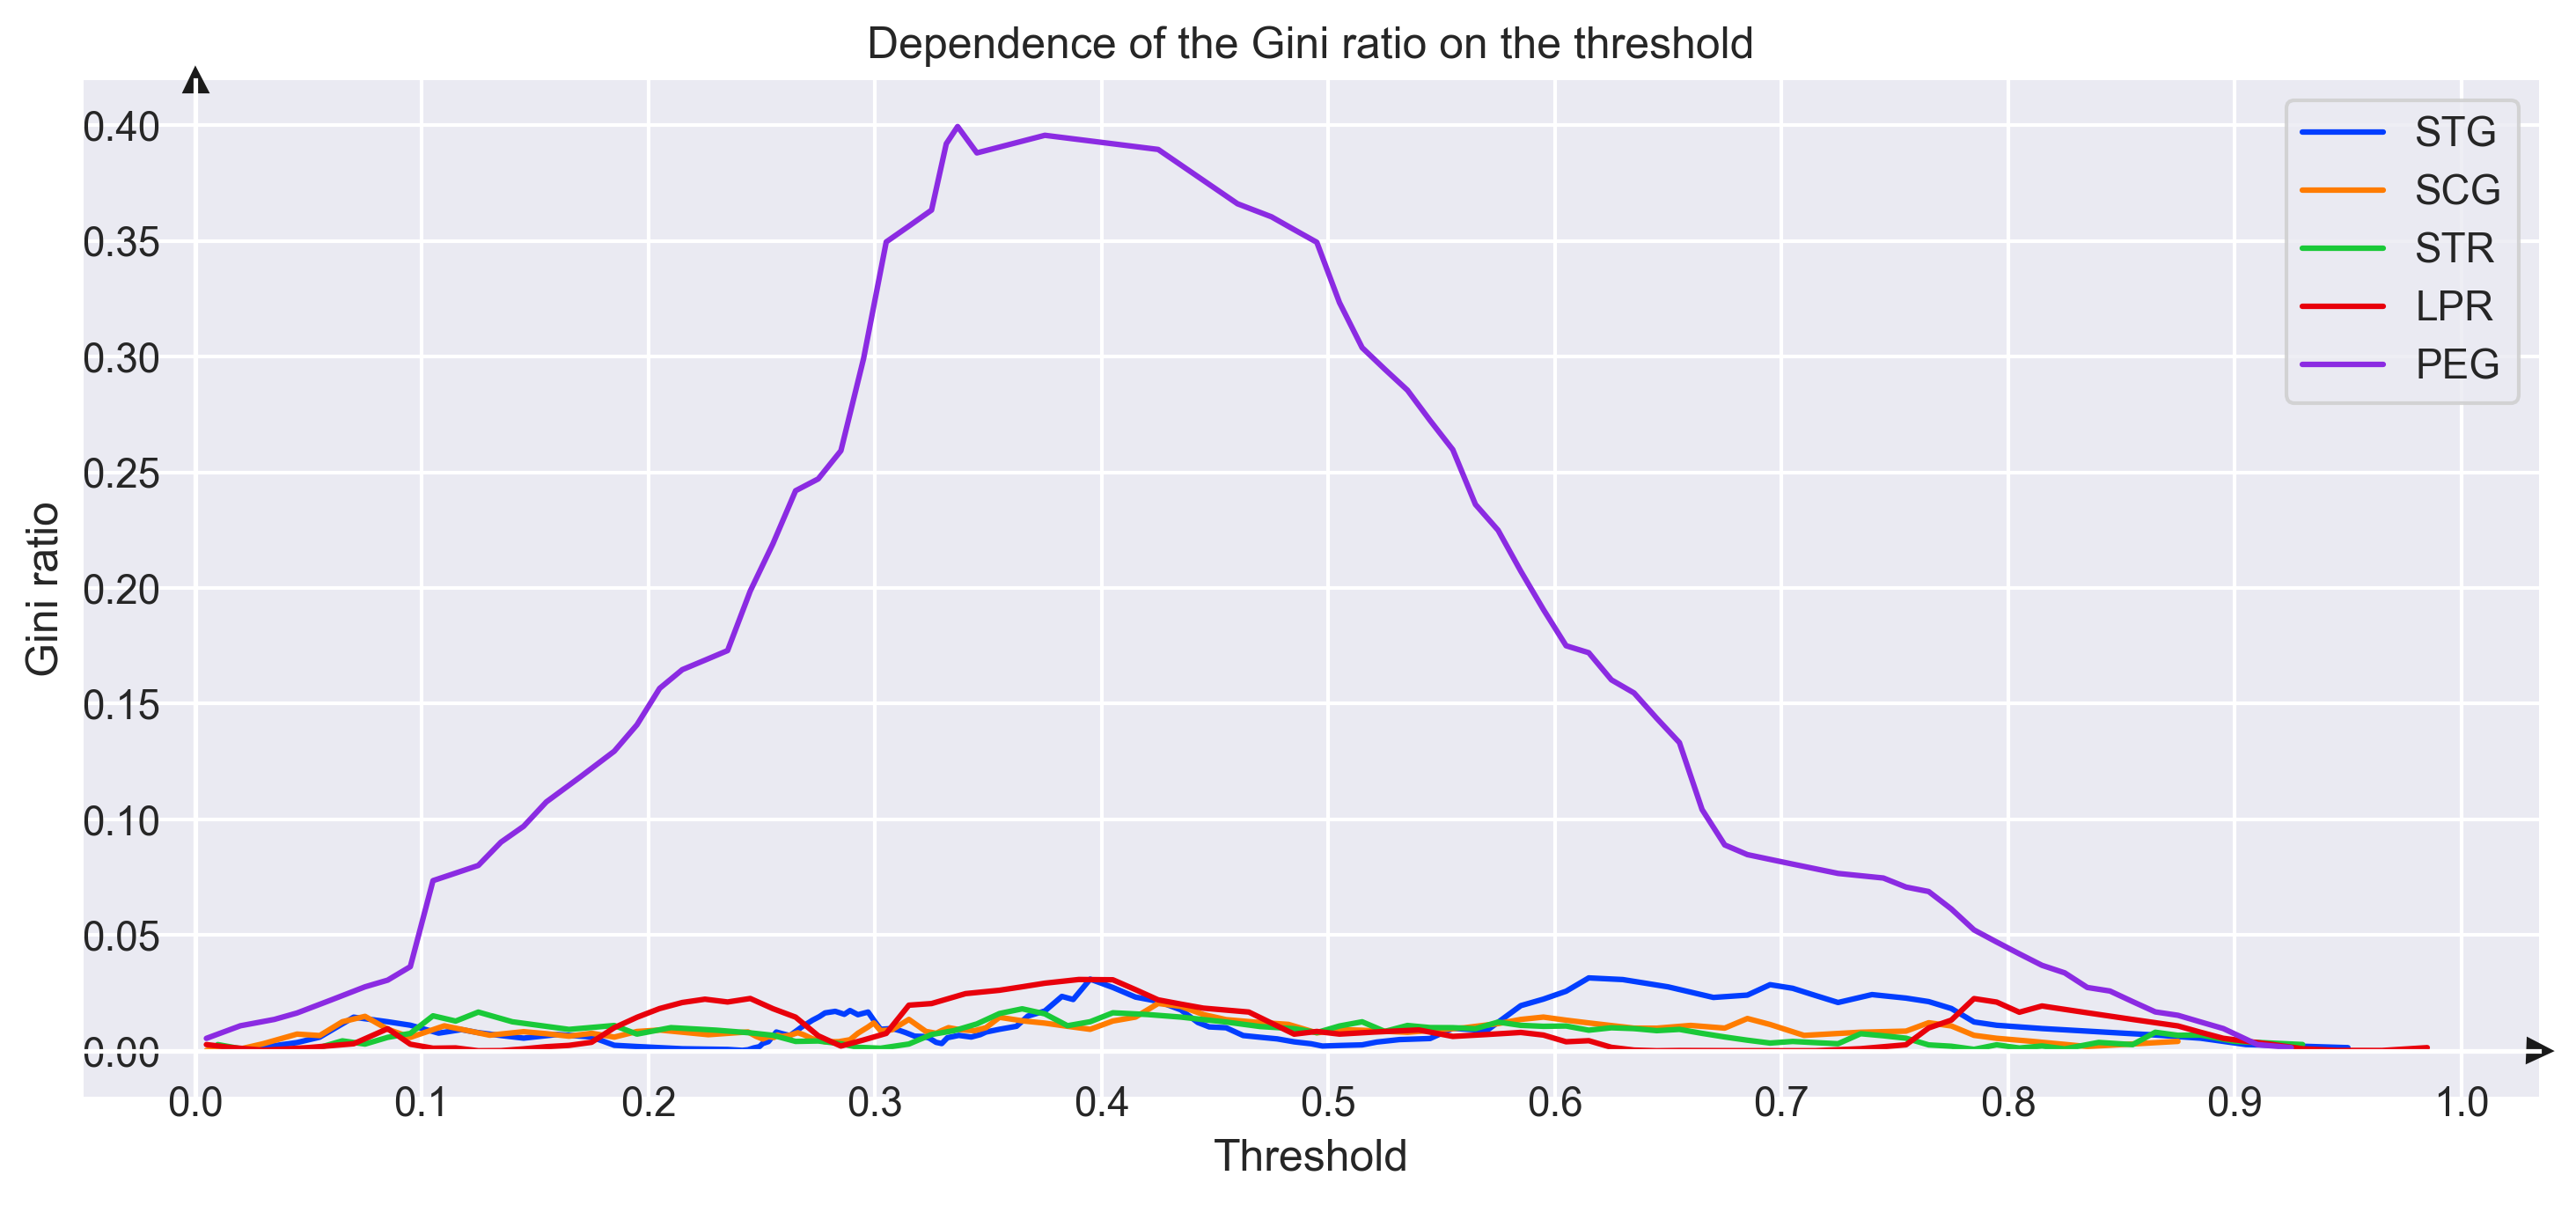

In [17]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

for i in range(5):
    thresholds, ginis, threshold_best, gini_best = find_best_split(np.array(X[X.columns[i]]), np.array(y), task="classification", feature_type="real")
    sns.lineplot(x=thresholds, y=ginis, label=X.columns[i])

ax.set_xlabel("Threshold")
ax.set_ylabel("Gini ratio")
ax.set_xticks(np.arange(0, 1.05, 0.1))
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
ax.spines["bottom"].set_position(("data", 0))
ax.spines["left"].set_position(("data", 0))
ax.plot(1, 0, "k>", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.set_title("Dependence of the Gini ratio on the threshold")
plt.show()


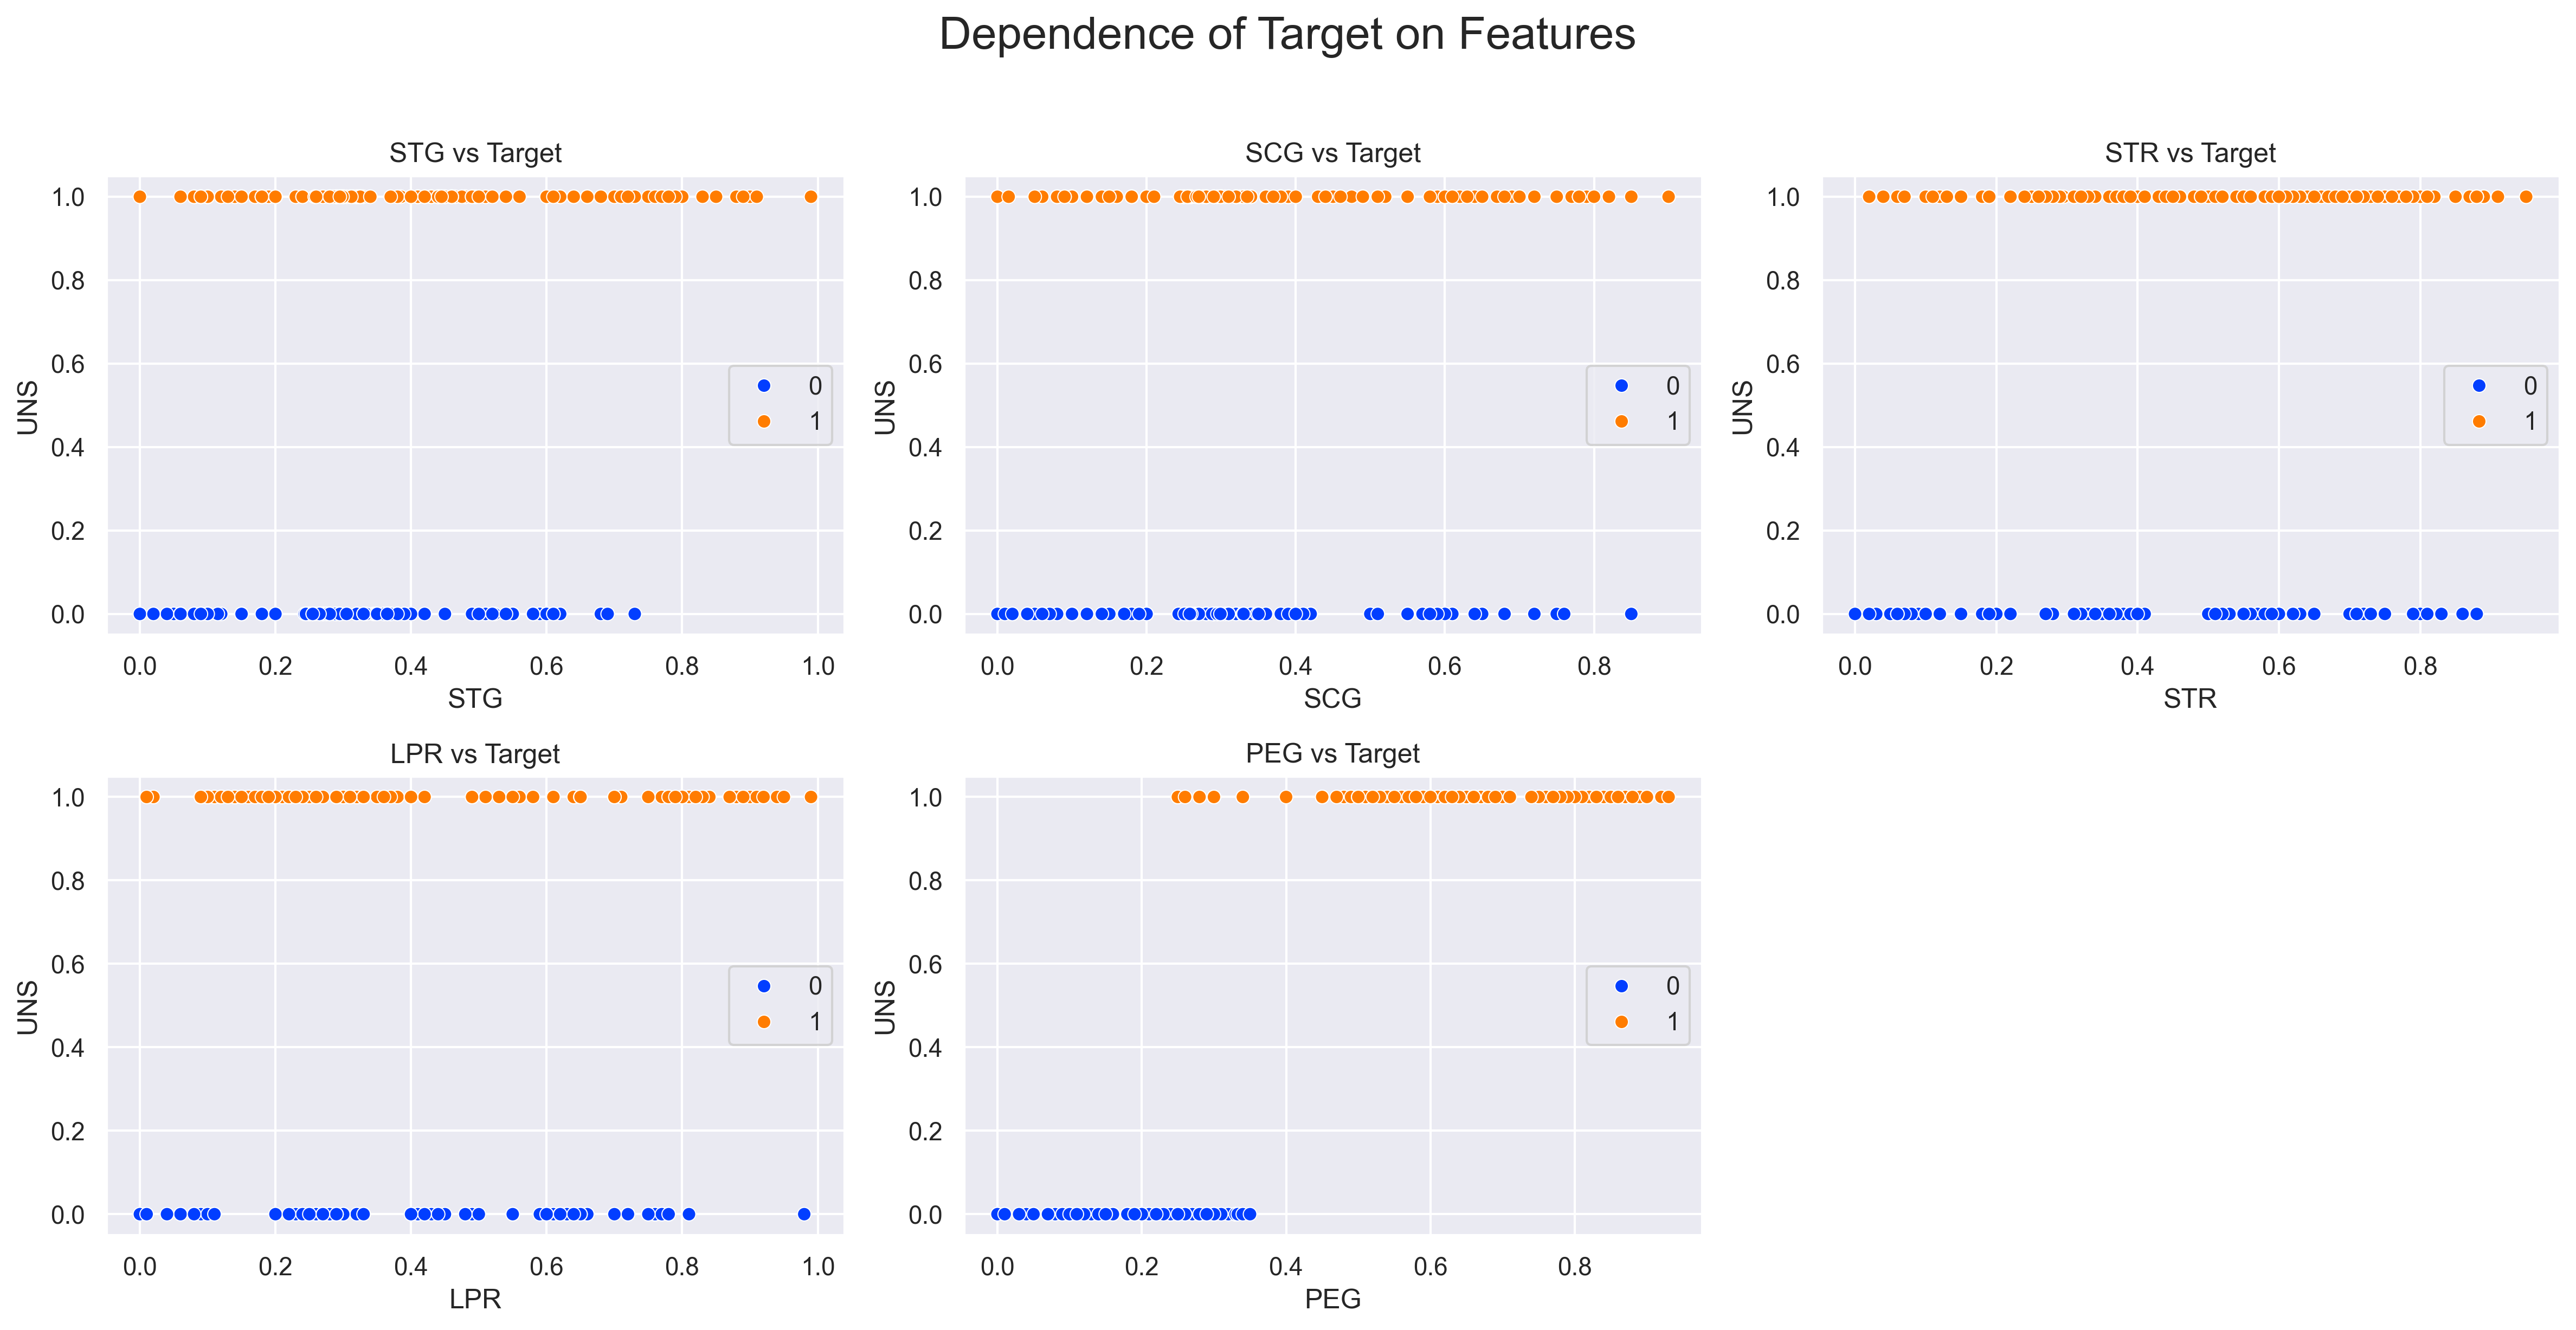

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=300)
axes = axes.flatten()

for i in range(5):
    sns.scatterplot(x=X[X.columns[i]], y=y, hue=y, ax=axes[i])
    axes[i].set_title(f"{X.columns[i]} vs Target")
    axes[i].legend(loc="center right")

axes[5].axis("off")

plt.suptitle("Dependence of Target on Features", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

Судя по первому графику, деление необходимо производить по признаку PEG, так как он единственный даёт высокое значение критерия Джини с максимальным значение около 
 при пороге деления приблизительно 
. Остальные признаки дают одинаковые значения меньше 
 при всех порогах.

Это же хорошо видно и по диаграммам рассеяиния - у признака PEG можно чётко разделить объекты по их классу (больше 
 первый класс, а то, что меньше - прктически все объекты относятся к другому классу), а у остальных признаков классы сильно перемешаны, потому что таргет 1 расположен почти на всём пространстве значений.



**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [19]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
mushroom = pd.read_csv("agaricus-lepiota.data", header=None)
mushroom.head()


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [20]:
X = mushroom.iloc[:, 1:] 
y = mushroom.iloc[:, 0] 

X.head(5)

,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,22
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [22]:
from sklearn.preprocessing import LabelEncoder
X = X.copy()

encoder = LabelEncoder()
for i in X.columns:
    X[i] = encoder.fit_transform(X[i])

y = encoder.fit_transform(y)

X.head()


,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,22
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.3, random_state=42)
tree = DecisionTree(np.array(["categorical" for _ in range(X_train.shape[1])]), task="classification")

tree.fit(X_train, y_train)
predict_train = tree.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, predict_train)}")

predict_test = tree.predict(X_test)
print(f"Test accuracy:  {accuracy_score(y_test, predict_test)}")



Train accuracy: 1.0
Test accuracy:  1.0


In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

tree = DecisionTree(
    feature_types=np.array(["categorical" for _ in range(X_train.shape[1])]),
    max_depth=3,
    min_samples_split=100,
    min_samples_leaf=50,
    task="classification"
)

tree.fit(X_train, y_train)
predict_train = tree.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, predict_train):.4f}")

predict_test = tree.predict(X_test)
print(f"Test accuracy:  {accuracy_score(y_test, predict_test):.4f}")

importances = tree.get_feature_importances()
feature_names = X.columns.to_list()
ranked = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
print("\nFeature importances:")
for name, value in ranked:
    print(f"{name}: {value:.4f}")


Train accuracy: 1.0000
Test accuracy:  1.0000

Feature importances:
4: 0.3724
8: 0.2581
5: 0.1771
11: 0.1375
20: 0.0273
7: 0.0166
13: 0.0096
2: 0.0014
1: 0.0000
3: 0.0000
6: 0.0000
9: 0.0000
10: 0.0000
12: 0.0000
14: 0.0000
15: 0.0000
16: 0.0000
17: 0.0000
18: 0.0000
19: 0.0000
21: 0.0000
22: 0.0000


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [24]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [25]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

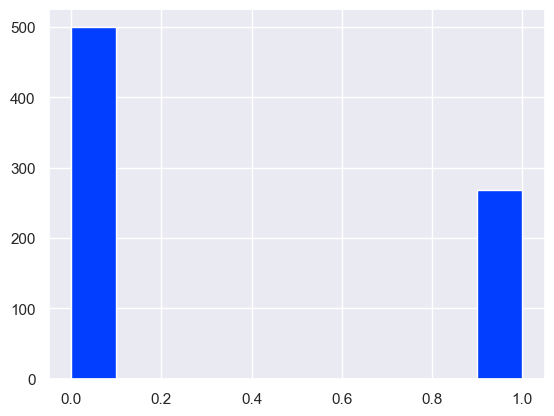

In [26]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
y = data['Outcome']
X = data.drop(columns='Outcome')
X

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [50]:


X_train, X_test , y_train, y_test = train_test_split(X.values, y , train_size=0.7,stratify=y, random_state=42)
X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(X_train, y_train, train_size=0.7, stratify=y_train, random_state=42)

print(X_train_train.shape, X_train_val.shape, X_test.shape, X_train.shape)

(375, 8) (162, 8) (231, 8) (537, 8)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [51]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.metrics import f1_score
from itertools import product

max_depths = [1,2,3,4,5,6,7,8,9,10]
min_samples_leafs = [ 1,2,3,4,5,6,7,8,9,10,15,20,25]


best_f1,  best_depth , best_leaf = -np.inf, None, None
for depth, leaf in product(max_depths, min_samples_leafs):
    tree = DecisionTreeClassifier(max_depth= depth,min_samples_leaf=leaf)
    tree.fit(X_train_train, y_train_train)
    f1 = f1_score(y_train_val, tree.predict(X_train_val))
    if f1 > best_f1:
        best_f1 = f1
        best_depth, best_leaf = depth, leaf
        
print(f"Best max_depth={best_depth}, min_samples_leaf={best_leaf}, f1={best_f1:.4f}")

Best max_depth=5, min_samples_leaf=20, f1=0.6250


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

best_tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42)

best_tree.fit(X_train,y_train)

accuracy = accuracy_score(y_test,best_tree.predict(X_test))
precision = precision_score(y_test,best_tree.predict(X_test))
recall = recall_score(y_test,best_tree.predict(X_test))
roc_auc = roc_auc_score(y_test,best_tree.predict(X_test))

print(accuracy, precision,recall, roc_auc)

0.7272727272727273 0.6451612903225806 0.49382716049382713 0.6735802469135802


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [53]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
bagging = BaggingClassifier(n_estimators=50,n_jobs=-1, random_state=42)
bagging.fit(X_train,y_train)

accuracy_bag = accuracy_score(y_test,bagging.predict(X_test))
precision_bag = precision_score(y_test,bagging.predict(X_test))
recall_bag = recall_score(y_test,bagging.predict(X_test))
roc_auc_bag = roc_auc_score(y_test,bagging.predict(X_test))

print(accuracy_bag, precision_bag,recall_bag, roc_auc_bag)

0.7532467532467533 0.6875 0.5432098765432098 0.7049382716049383


In [54]:
print(f"diff accuracy: {accuracy-accuracy_bag}")
print(f"diff precision: {precision-precision_bag}")
print(f"diff recall: {recall-recall_bag}")
print(f"diff roc_auc: {roc_auc-roc_auc_bag}")

diff accuracy: -0.025974025974025983
diff precision: -0.04233870967741937
diff recall: -0.04938271604938271
diff roc_auc: -0.031358024691358066


Видим, что у беггинга все метрики выше чем у 1 дерева, что не удивительно

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [67]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20]
}

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

grid_search = GridSearchCV(rf, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best f1: {grid_search.best_score_:.4f}")

best_depth, best_split = grid_search.best_params_['max_depth'], grid_search.best_params_['min_samples_split']
# Лучшая модель уже обучена на всех данных
best_rf = grid_search.best_estimator_

Best params: {'max_depth': 10, 'min_samples_split': 5}
Best f1: 0.6321


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

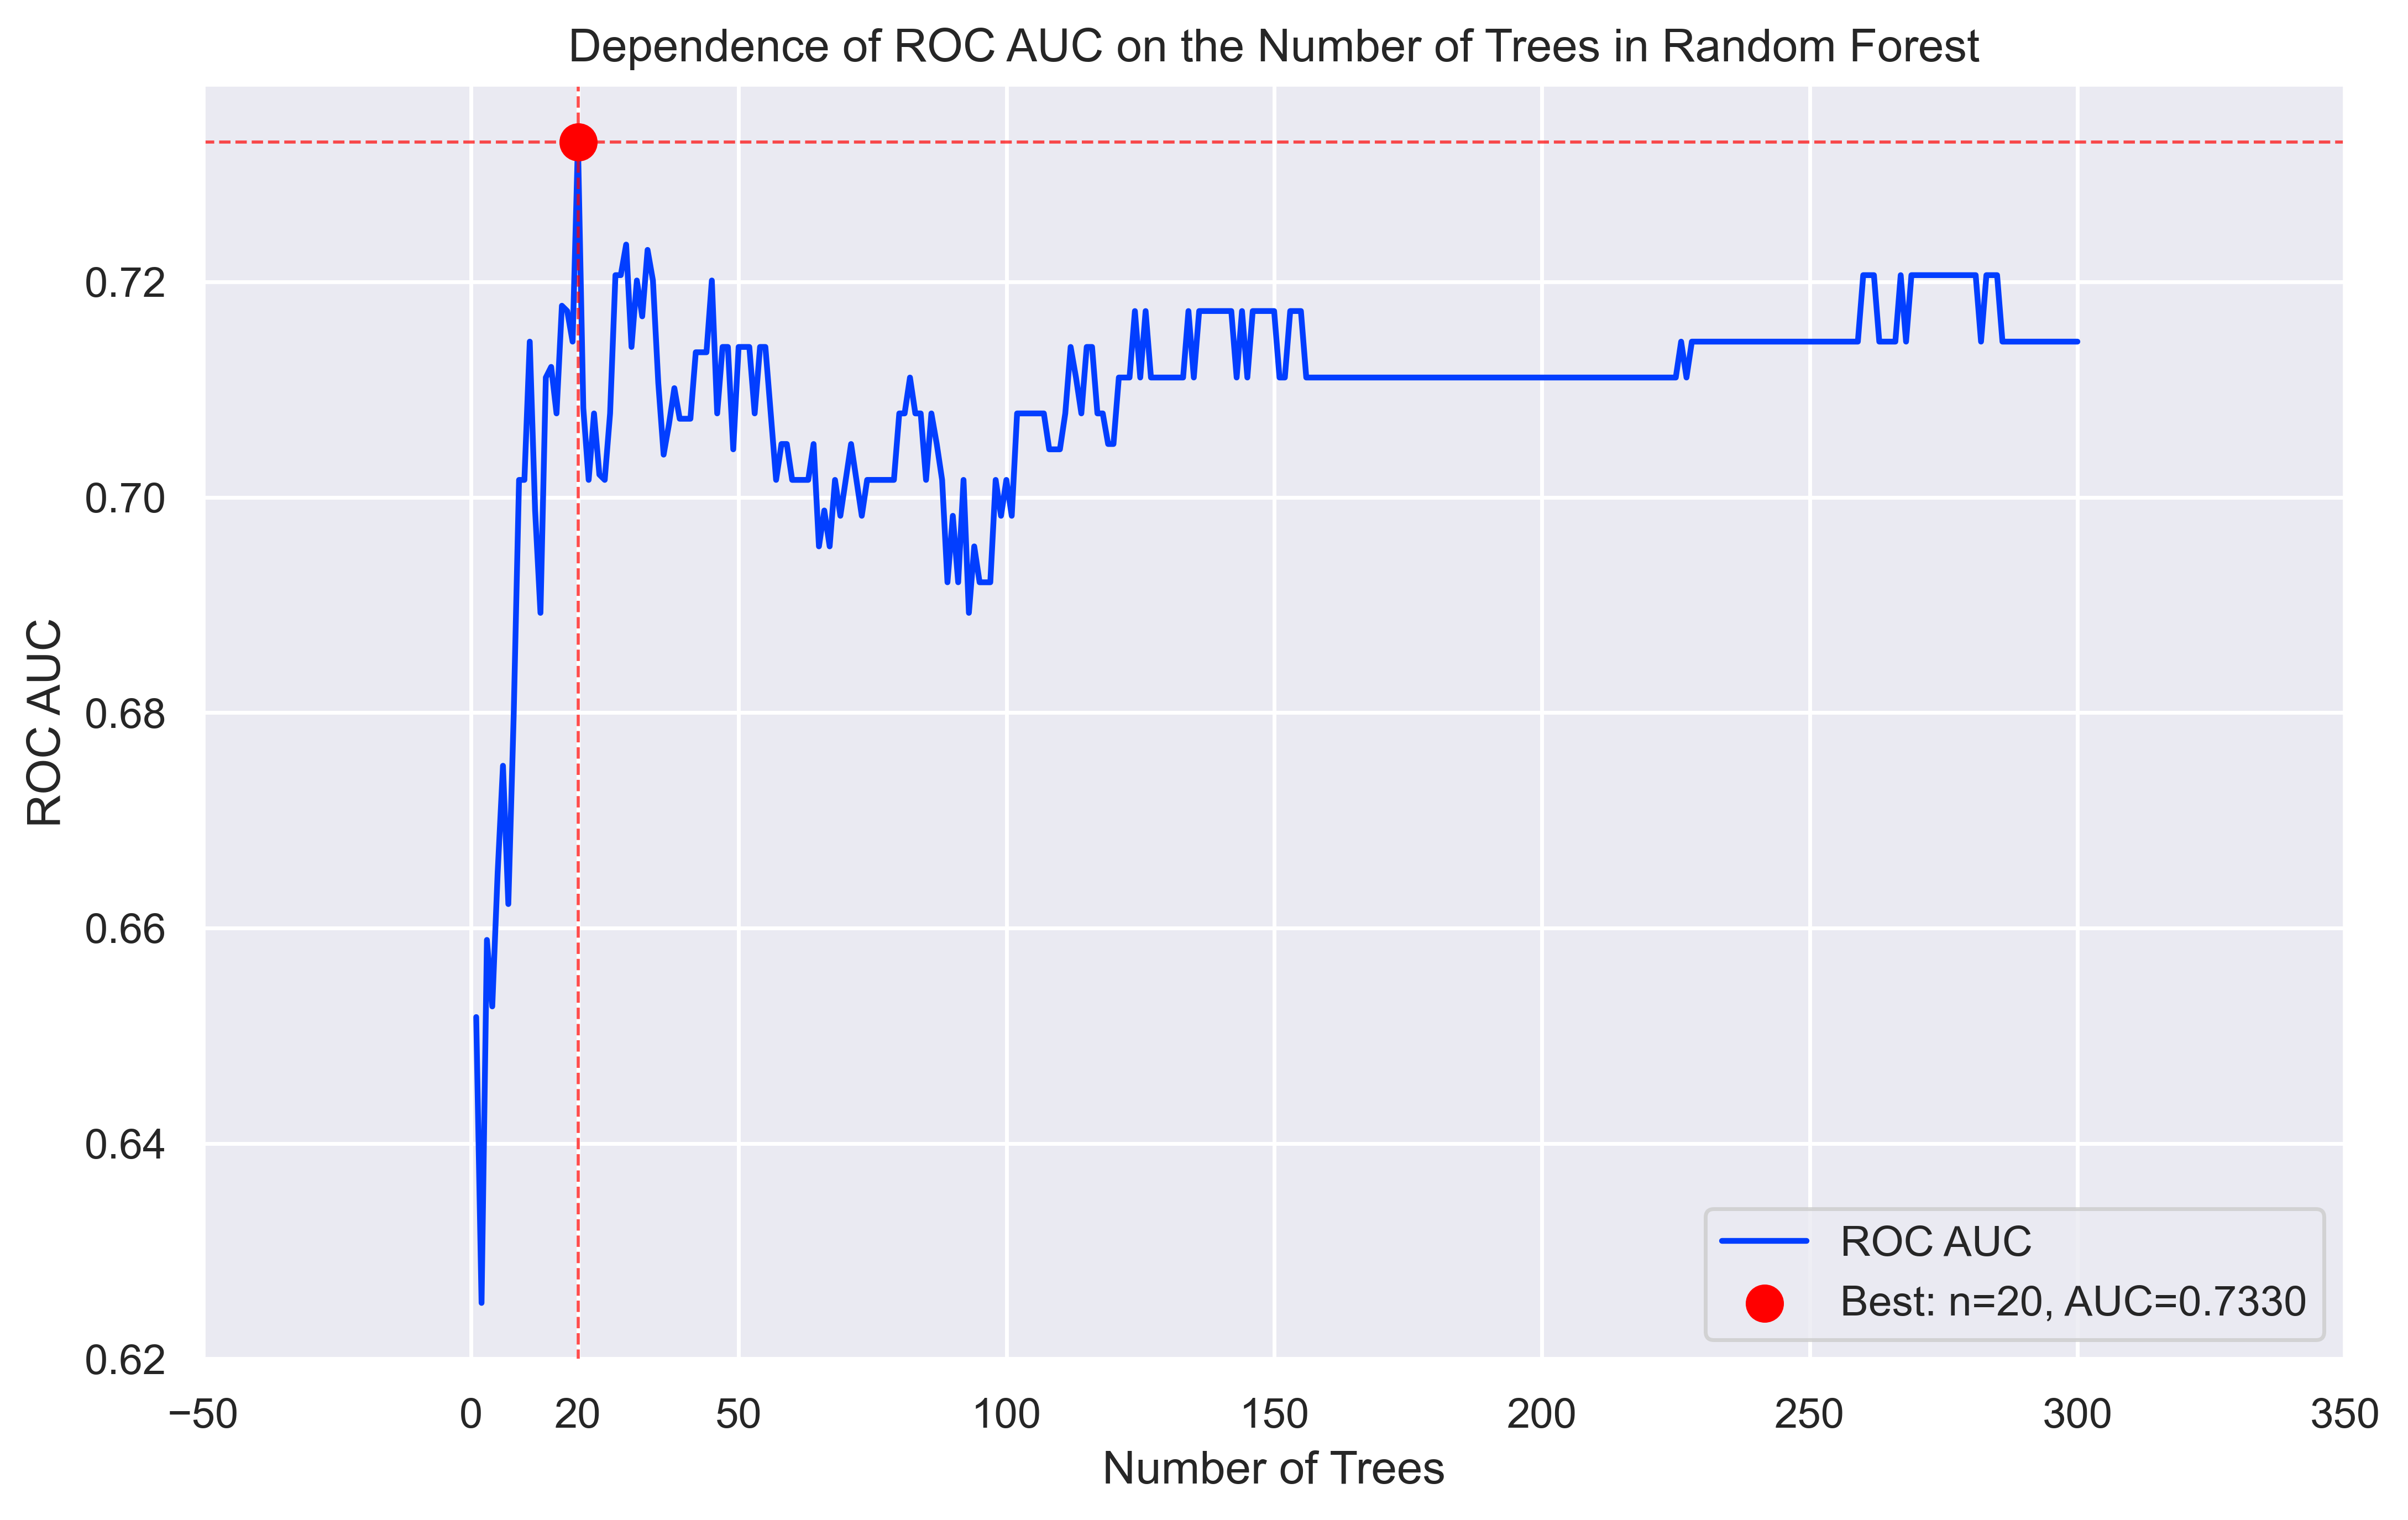

Лучшее количество деревьев: 20, ROC AUC = 0.7330


In [75]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
fig, ax = plt.subplots(figsize=(10, 6), dpi=500)

roc_auc_values = []

for i in range(1, 301):
    rf = RandomForestClassifier(n_estimators=i, max_depth=best_depth, min_samples_split=best_split, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    roc_auc_values.append(roc_auc_score(y_test, rf.predict(X_test)))
    
best_n = np.argmax(roc_auc_values) + 1
best_roc = roc_auc_values[best_n - 1]

ax.plot(range(1, 301), roc_auc_values, linewidth=1.5, label="ROC AUC")

ax.scatter(best_n, best_roc, color="red", zorder=5, s=80, label=f"Best: n={best_n}, AUC={best_roc:.4f}")

ax.axvline(x=best_n, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axhline(y=best_roc, color="red", linestyle="--", linewidth=0.8, alpha=0.7)

current_xticks = list(ax.get_xticks())
current_xticks.append(best_n)
ax.set_xticks(current_xticks)

ax.set_xlabel("Number of Trees")
ax.set_ylabel("ROC AUC")
ax.set_title("Dependence of ROC AUC on the Number of Trees in Random Forest")
ax.legend()
plt.show()

print(f"Лучшее количество деревьев: {best_n}, ROC AUC = {best_roc:.4f}")

Видно, что до определенного количества деревьев `ROC-AUC` растет, после чего колебается примерно вокруг `0.71` и стагнирует. Но по графику видно, что лучшее количество деревьев по `ROC-AUC`  это примерно 20

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

In [76]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

best_rf = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth, min_samples_split=best_split, random_state=42, n_jobs=-1)
best_rf.fit(X_train,y_train)
importances = best_rf.feature_importances_
feature_names = X.columns.to_list()
ranked = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
print("\nFeature importances:")
for name, value in ranked:
    print(f"{name}: {value:.4f}")



Feature importances:
Glucose: 0.2887
BMI: 0.1660
Age: 0.1276
DiabetesPedigreeFunction: 0.1138
Pregnancies: 0.0934
BloodPressure: 0.0802
Insulin: 0.0666
SkinThickness: 0.0637


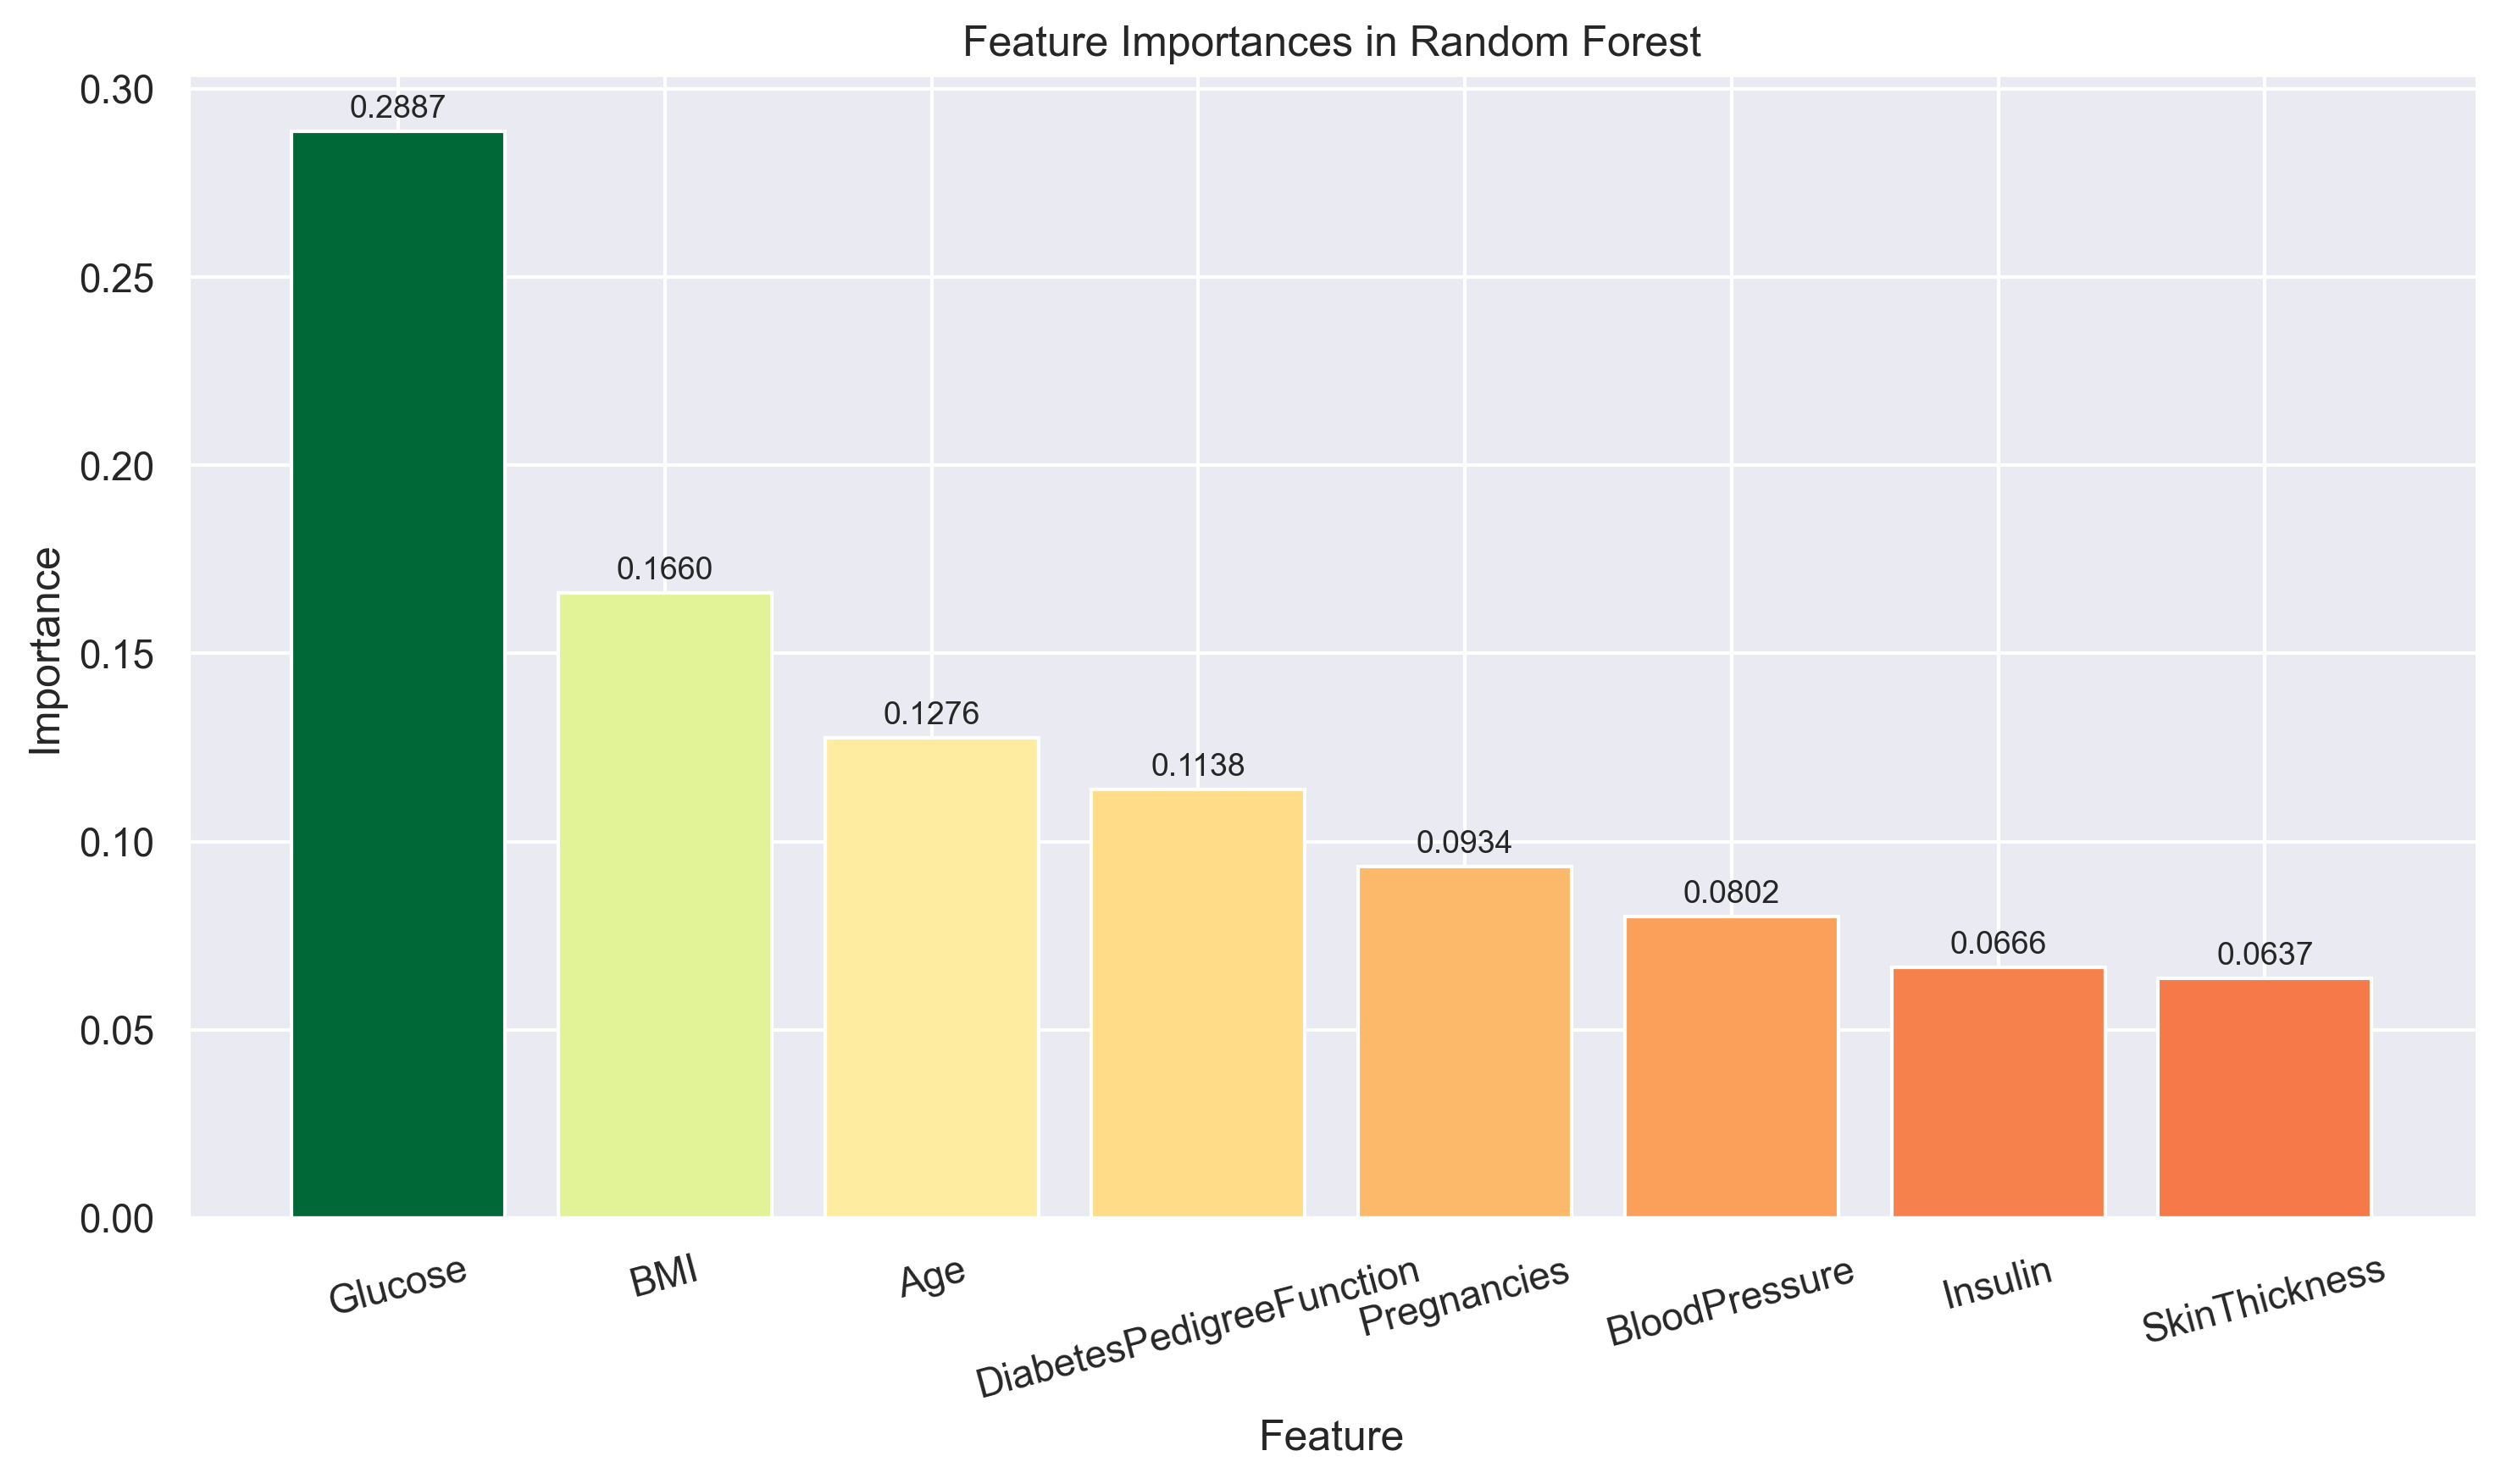

Самый важный признак: Glucose (0.2887)


In [ ]:

sorted_idx = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_importances = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bars = ax.bar(sorted_names, sorted_importances, color=plt.cm.RdYlGn(sorted_importances / sorted_importances.max()))

for bar, val in zip(bars, sorted_importances):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
ax.set_title("Feature Importances in Random Forest")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Самый важный признак: {sorted_names[0]} ({sorted_importances[0]:.4f})")

Самым важным признаков оказался уровень глюкозы в крови, что довольно логично для определения есть ли диабет у человека или нет